# **KNN REGRESSION**    

# **Import Library**

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt


# **Load Dataset**

In [2]:
# Pastikan file CSV hasil preprocessing sudah diunggah
df = pd.read_csv("NO2_Kwanyar_Preprocessed.csv")

# Tampilkan beberapa data awal
df.head()


,Tanggal,NO2,NO2_t-1,NO2_t-2,NO2_t-3
0,2023-01-13,0.000026,0.000007,0.000053,0.000049
1,2023-01-14,0.000034,0.000026,0.000007,0.000053
2,2023-01-15,0.000005,0.000034,0.000026,0.000007
3,2023-05-07,0.000024,0.000033,0.000018,0.000011
4,2023-05-08,0.000016,0.000024,0.000033,0.000018


# **Pisahkan Fitur (X) dan Target (y)**

Pada supervised data hasil preprocessing, biasanya kita punya kolom seperti NO2(t-1) dan target NO2(t).

In [3]:
# === 1. Pisahkan fitur dan target ===
X = df.drop(columns=['Tanggal', 'NO2'])  # fitur: NO2_t-1, NO2_t-2, NO2_t-3
y = df['NO2']                            # target: NO2 aktual

# **Normalisasi Data**

KNN sangat sensitif terhadap skala data, karena menghitung jarak antar titik (biasanya Euclidean).
Oleh karena itu, semua fitur dinormalisasi dengan MinMaxScaler ke rentang [0, 1].

In [4]:
# === 2. Normalisasi fitur numerik ===
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# **Split Data**
Data dibagi menjadi:

80% untuk pelatihan (X_train, y_train)

20% untuk pengujian (X_test, y_test)
Karena ini data deret waktu (time series), shuffle=False digunakan agar urutan waktu tidak acak.

In [5]:
# === 3. Split data untuk training dan testing ===
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, shuffle=False
)

# **Pelatihan Model**
Model KNN Regression dilatih dengan n_neighbors=3, artinya prediksi dibuat berdasarkan rata-rata dari 3 titik data terdekat.

In [6]:
# === 4. Inisialisasi dan latih model KNN Regressor ===
knn = KNeighborsRegressor(n_neighbors=3)  # kamu bisa ubah jumlah tetangga (k)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# **Evaluasi Performa**
Beberapa metrik digunakan:

MAE (Mean Absolute Error) → rata-rata selisih absolut antara aktual dan prediksi.

RMSE (Root Mean Squared Error) → penalti lebih besar untuk kesalahan besar.

R² Score → mengukur seberapa baik model menjelaskan variasi data (semakin mendekati 1 semakin baik).

In [7]:
# === 5. Prediksi data test ===
y_pred = knn.predict(X_test)

# **Visualisasi**
Grafik menampilkan perbandingan antara data aktual dan hasil prediksi.
Semakin berdekatan garis biru (aktual) dan merah (prediksi), semakin akurat model KNN.

=== Evaluasi Model KNN Regression ===
Mean Absolute Error (MAE) : 0.000011
Root Mean Squared Error (RMSE): 0.000014
R² Score: -0.101100
Mean Absolute Percentage Error (MAPE): 108.98%


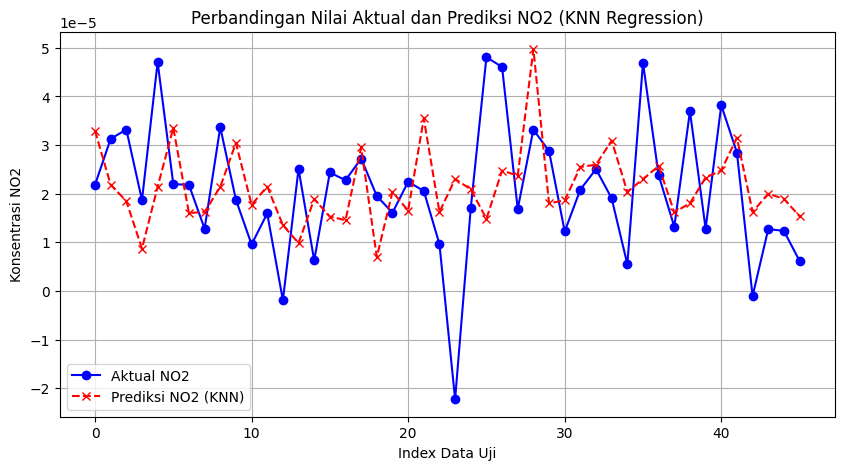

In [8]:
# === 6. Evaluasi performa model ===
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) 

print("=== Evaluasi Model KNN Regression ===")
print(f"Mean Absolute Error (MAE) : {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape*100:.2f}%") 

# === 7. Visualisasi hasil prediksi vs aktual ===
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Aktual NO2", color='blue', marker='o')
plt.plot(y_pred, label="Prediksi NO2 (KNN)", color='red', linestyle='--', marker='x')
plt.title("Perbandingan Nilai Aktual dan Prediksi NO2 (KNN Regression)")
plt.xlabel("Index Data Uji")
plt.ylabel("Konsentrasi NO2")
plt.legend()
plt.grid(True)
plt.show()